# TỔNG QUAN TOÀN DỰ ÁN — Competitor Fare Forecasting

> **Chạy `Run All` để lấy toàn bộ số liệu cập nhật.** Notebook này **không train gì cả** — nó đọc
> kết quả đã có và tính lại phần acceptance (rất nhẹ). Thời gian chạy ~1 phút.

## Đề bài — 3 cấu phần

| # | Cấu phần | Câu hỏi |
|---|---|---|
| **(i)** | Study relation | Feature nào ảnh hưởng giá đối thủ, ảnh hưởng thế nào? |
| **(ii)** | Build model | Dự đoán giá đối thủ ở thời điểm tương lai |
| **(iii)** | Uncertainty | Khoảng tin cậy quanh dự đoán đó |
| **(+)** | Acceptance *(mentor yêu cầu thêm)* | Khách chấp nhận giá mình báo với xác suất bao nhiêu? |

## Bản đồ notebook

```
  data/                    hcm_train_ready.parquet
    │
    ├── analysis/          (i)  13 notebook phân tích  +  90_sinh_hinh_bao_cao_tuan2
    │
    ├── model/train/       (ii) 01 giá cơ bản · 02 hệ số nhân · 03 giá trực tiếp · 04 GAM
    │     └── evaluation/       01-05 đánh giá · 06 UQ plot · 07 theo góp ý mentor
    │
    ├── model/uncertainty/ (iii) 01 conformal · 02 quantile + CQR
    │
    └── model/acceptance/  (+)  00 TỔNG HỢP  ·  01-06 chi tiết
                                07 chi phí biên + uncertainty   ← nối (ii)(iii) vào (+)
                                08 MNL 3 lựa chọn
                                09 đối chiếu literature
```

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
EVAL = Path("evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 170)

KQ = {}          # gom moi so lieu chinh vao day
print("San sang.")

San sang.


## Cấu phần (ii) — Model dự đoán giá đối thủ

In [2]:
# ── So sanh 4 thuat toan tren tap test ──
pg = pd.read_parquet(EVAL / "pred_gia.parquet",
                     columns=["split", "algo", "pred", "target_shown_price",
                              "persistence_prediction", "requested_lag_minutes"])
pg = pg[pg.split == "test"]

rows = []
for algo, g in pg.groupby("algo", observed=True):
    mae = (g.pred - g.target_shown_price).abs().mean()
    mape = ((g.pred - g.target_shown_price).abs() / g.target_shown_price).mean()
    rows.append({"Thuật toán": algo, "MAE (đ)": round(mae), "MAPE": f"{mape:.2%}",
                 "n": len(g)})
# GAM luu o file rieng -> gop vao cho du 4 thuat toan
gam = pd.read_parquet(EVAL / "pred_gam.parquet",
                      columns=["split", "gia_that", "truc_tiep_pred"])
gam = gam[gam.split == "test"]
rows.append({"Thuật toán": "GAM",
             "MAE (đ)": round((gam.truc_tiep_pred - gam.gia_that).abs().mean()),
             "MAPE": f"{((gam.truc_tiep_pred-gam.gia_that).abs()/gam.gia_that).mean():.2%}",
             "n": len(gam)})

g0 = pg[pg.algo == pg.algo.iloc[0]]
mae_pers = (g0.persistence_prediction - g0.target_shown_price).abs().mean()
bang_algo = pd.DataFrame(rows).sort_values("MAE (đ)").reset_index(drop=True)
bang_algo = pd.concat([bang_algo, pd.DataFrame([{
    "Thuật toán": "— Persistence (mốc so sánh)", "MAE (đ)": round(mae_pers),
    "MAPE": f"{((g0.persistence_prediction-g0.target_shown_price).abs()/g0.target_shown_price).mean():.2%}",
    "n": len(g0)}])], ignore_index=True)
print("Model GIA TRUC TIEP — so sanh thuat toan (tap test)")
display(bang_algo)

# ── Hybrid (gia co ban x he so nhan) ──
uq = pd.read_parquet(EVAL / "uq_pred_test.parquet")
mae_hyb = (uq.hybrid_pred - uq.gia_that).abs().mean()
mae_base = (uq.base_pred - uq.base_that).abs().mean()
mae_heso = (uq.heso_pred - uq.heso_that).abs().mean()

KQ["mae_hybrid"] = mae_hyb
KQ["mae_base"] = mae_base
KQ["mae_heso"] = mae_heso
KQ["mape_hybrid"] = ((uq.hybrid_pred - uq.gia_that).abs() / uq.gia_that).mean()
KQ["n_test"] = len(uq)

print(f"\nModel HYBRID (gia co ban x he so nhan) — {len(uq):,} chuyen test")
print(f"  MAE gia cuoi     : {mae_hyb:>10,.0f} d   ({KQ['mape_hybrid']:.2%})")
print(f"  MAE gia co ban   : {mae_base:>10,.0f} d")
print(f"  MAE he so nhan   : {mae_heso:>10.4f}")

chenh = bang_algo[bang_algo["Thuật toán"] != "— Persistence (mốc so sánh)"]["MAE (đ)"]
KQ["n_algo"] = len(chenh)
KQ["chenh_algo"] = (chenh.max() / chenh.min() - 1) * 100
KQ["mae_pers"] = mae_pers
print(f"\n{KQ['n_algo']} thuat toan chenh nhau {KQ['chenh_algo']:.1f}% "
      f"({chenh.min():,} - {chenh.max():,} d)")
print(f"Deu tot hon persistence ({mae_pers:,.0f} d) "
      f"khoang {(1-chenh.min()/mae_pers)*100:.0f}%.")
print("=> Chon thuat toan KHONG phai don bay chinh. Gioi han nam o DU LIEU.")

Model GIA TRUC TIEP — so sanh thuat toan (tap test)


,Thuật toán,MAE (đ),MAPE,n
0,XGBoost,18807,15.34%,864360
1,LightGBM,18809,15.34%,864360
2,HistGB,18834,15.36%,864360
3,GAM,19173,15.70%,864360
4,— Persistence (mốc so sánh),33683,28.18%,864360



Model HYBRID (gia co ban x he so nhan) — 864,360 chuyen test
  MAE gia cuoi     :     18,048 d   (14.74%)
  MAE gia co ban   :     15,032 d
  MAE he so nhan   :     0.0233

4 thuat toan chenh nhau 1.9% (18,807 - 19,173 d)
Deu tot hon persistence (33,683 d) khoang 44%.
=> Chon thuat toan KHONG phai don bay chinh. Gioi han nam o DU LIEU.


## Cấu phần (iii) — Uncertainty Quantification

In [3]:
qt = pd.read_parquet(EVAL / "qr_pred_test.parquet")
qc = pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")

MUC = 0.90

# ── Conformal chuan hoa (tren model hybrid) ──
sai_so_rel = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred)
q_rel = np.quantile(sai_so_rel, MUC)
lo = uq.hybrid_pred * (1 - q_rel); hi = uq.hybrid_pred * (1 + q_rel)
cov_conf = ((uq.gia_that >= lo) & (uq.gia_that <= hi)).mean()
rong_conf = (hi - lo).mean()

# ── CQR ──
E = np.maximum(qc.q05 - qc.gia_that, qc.gia_that - qc.q95)
k = min(int(np.ceil((len(qc) + 1) * MUC)), len(qc))
q_cqr = np.sort(E.values)[k - 1]
lo_c = qt.q05 - q_cqr; hi_c = qt.q95 + q_cqr
cov_cqr = ((qt.gia_that >= lo_c) & (qt.gia_that <= hi_c)).mean()
rong_cqr = (hi_c - lo_c).mean()

# ── Quantile Regression tho (khong hieu chinh) ──
cov_qr = ((qt.gia_that >= qt.q05) & (qt.gia_that <= qt.q95)).mean()
rong_qr = (qt.q95 - qt.q05).mean()

bang_uq = pd.DataFrame([
    {"Phương pháp": "Conformal chuẩn hoá", "Coverage": f"{cov_conf:.2%}",
     "Độ rộng TB (đ)": round(rong_conf), "Hiệu chỉnh": "có"},
    {"Phương pháp": "Quantile Regression (thô)", "Coverage": f"{cov_qr:.2%}",
     "Độ rộng TB (đ)": round(rong_qr), "Hiệu chỉnh": "không"},
    {"Phương pháp": "CQR (QR + conformal)", "Coverage": f"{cov_cqr:.2%}",
     "Độ rộng TB (đ)": round(rong_cqr), "Hiệu chỉnh": "có"},
])
print(f"Muc danh muc: {MUC:.0%}   |   Tap test: {len(qt):,} chuyen")
display(bang_uq)

KQ.update(dict(q_rel=q_rel, cov_conf=cov_conf, rong_conf=rong_conf,
               cov_cqr=cov_cqr, rong_cqr=rong_cqr, cov_qr=cov_qr, rong_qr=rong_qr))
print(f"\nConformal chuan hoa: khoang = du_doan x (1 +/- {q_rel:.2%})")

# ── Coverage theo nhom (dieu kien) — chi tieu quan trong hon coverage tong ──
print("\nCOVERAGE THEO GIO (lech so voi danh muc 90%) — cang deu cang tot:")
tmp = qt.copy()
tmp["trong_cqr"] = (tmp.gia_that >= tmp.q05 - q_cqr) & (tmp.gia_that <= tmp.q95 + q_cqr)
tmp["trong_qr"] = (tmp.gia_that >= tmp.q05) & (tmp.gia_that <= tmp.q95)
byg = tmp.groupby("gio_vn")[["trong_cqr", "trong_qr"]].mean() * 100
print(f"  CQR : lech max {(byg.trong_cqr - 90).abs().max():.2f} diem")
print(f"  QR  : lech max {(byg.trong_qr  - 90).abs().max():.2f} diem")
KQ["lech_cqr"] = (byg.trong_cqr - 90).abs().max()
KQ["lech_qr"] = (byg.trong_qr - 90).abs().max()

Muc danh muc: 90%   |   Tap test: 864,360 chuyen


,Phương pháp,Coverage,Độ rộng TB (đ),Hiệu chỉnh
0,Conformal chuẩn hoá,89.55%,72630,có
1,Quantile Regression (thô),89.09%,75783,không
2,CQR (QR + conformal),89.54%,76449,có



Conformal chuan hoa: khoang = du_doan x (1 +/- 30.09%)

COVERAGE THEO GIO (lech so voi danh muc 90%) — cang deu cang tot:
  CQR : lech max 1.91 diem
  QR  : lech max 2.36 diem


## Acceptance model — tính lại toàn bộ (nhẹ, không cần dữ liệu)

In [4]:
# ═══ Tham so (dong bo voi 00_TONG_HOP, 07, 08) ═══
P0, EPS_FIRM, EPS_MARKET, THI_PHAN = 0.50, -2.0, -0.5, 0.50
C_CHINH = 0.50
R_GRID = np.linspace(0.40, 2.20, 1801)


def P_accept(r, eps=EPS_FIRM, P0=P0):
    b = eps / (1 - P0); a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * np.log(r))))


# ── 1. Model 1: doi gia so voi doi thu ──
print("MODEL 1 — thay doi TUONG DOI kha nang chap nhan")
goc = P_accept(1.0)
for p in [0.05, 0.10, 0.20]:
    print(f"  Tang gia {p:+.0%}  ->  chap nhan {P_accept(1+p)/goc-1:+6.0%}")
for p in [-0.05, -0.10, -0.20]:
    print(f"  Giam gia {p:+.0%}  ->  chap nhan {P_accept(1+p)/goc-1:+6.0%}")
KQ["chap_nhan_p10"] = P_accept(1.10)/goc - 1

# ── 2. MNL: suy nguoc s0 ──
R = EPS_FIRM / EPS_MARKET
s0 = (1 - THI_PHAN) / (R - THI_PHAN)
s1 = THI_PHAN * (1 - s0)
beta = -EPS_MARKET / s0
KQ.update(s0=s0, s1=s1, beta=beta)
print(f"\nMNL — s0 (khong di) = {s0:.1%} | s1 (minh) = {s1:.1%} | beta = {beta:.3f}")
print(f"      Kiem tra: s0 trong [5%,30%]? {'CO ✅' if 0.05<=s0<=0.30 else 'KHONG ❌'}")

# ── 3. Gia toi uu co chi phi bien ──
def toi_uu(c, eps=EPS_FIRM):
    v = (R_GRID - c) * P_accept(R_GRID, eps)
    return R_GRID[int(np.argmax(v))]

cs = np.linspace(0, 0.95, 191)
print(f"\nGIA TOI UU (loi nhuan = (p - MC) x P(chap nhan))")
for c in [0.0, 0.25, 0.50, 0.75]:
    r = toi_uu(c)
    print(f"  c = {c:.0%}  ->  r* = {r:.3f}  ({(r-1)*100:+.1f}% so voi doi thu)")

print(f"\nNGUONG DAO CHIEU c* (r* = 1.0) — BAN NGAY THO, chua tinh bat dinh:")
for eps in [-1.2, -2.0, -3.0]:
    rr = np.array([toi_uu(c, eps) for c in cs])
    c_star = np.interp(1.0, rr, cs)
    print(f"  eps = {eps:5.1f}  ->  c* = {c_star:5.1%}")
    if eps == EPS_FIRM:
        KQ["c_star"] = c_star
KQ["r_star_c50"] = toi_uu(0.50)
print("\n  Luu y: nb 07 tinh lai c* CO tich phan tren phan phoi du doan")
print("         -> c* = 44.4% (eps=-2.0). Chenh vi bat dinh day dinh loi nhuan dich.")
print("  Ca hai deu duoi 75-80% (ty le an chia tai xe) => ket luan KHONG doi:")
print("         voi chi phi bien thuc te cua nganh, nen bao gia CAO HON doi thu.")

MODEL 1 — thay doi TUONG DOI kha nang chap nhan
  Tang gia +5%  ->  chap nhan   -10%
  Tang gia +10%  ->  chap nhan   -19%
  Tang gia +20%  ->  chap nhan   -35%
  Giam gia -5%  ->  chap nhan   +10%
  Giam gia -10%  ->  chap nhan   +21%
  Giam gia -20%  ->  chap nhan   +42%

MNL — s0 (khong di) = 14.3% | s1 (minh) = 42.9% | beta = 3.500
      Kiem tra: s0 trong [5%,30%]? CO ✅

GIA TOI UU (loi nhuan = (p - MC) x P(chap nhan))
  c = 0%  ->  r* = 0.760  (-24.0% so voi doi thu)
  c = 25%  ->  r* = 0.859  (-14.1% so voi doi thu)
  c = 50%  ->  r* = 1.000  (+0.0% so voi doi thu)
  c = 75%  ->  r* = 1.195  (+19.5% so voi doi thu)

NGUONG DAO CHIEU c* (r* = 1.0) — BAN NGAY THO, chua tinh bat dinh:
  eps =  -1.2  ->  c* = 16.6%
  eps =  -2.0  ->  c* = 50.0%
  eps =  -3.0  ->  c* = 66.7%

  Luu y: nb 07 tinh lai c* CO tich phan tren phan phoi du doan
         -> c* = 44.4% (eps=-2.0). Chenh vi bat dinh day dinh loi nhuan dich.
  Ca hai deu duoi 75-80% (ty le an chia tai xe) => ket luan KHONG doi:

## Kiến trúc hệ thống — từ dự đoán giá đến dự đoán chấp nhận

Nguyên tắc xuyên suốt: **tách bạch phần HỌC và phần GIẢ ĐỊNH**. Trộn hai thứ này là ra
"model AUC 1,0" nguỵ trang (đã chứng minh ở `acceptance/05_thu_nghiem_pseudo_label.ipynb`).

| Tầng | Bản chất | Có train? | Đánh giá bằng |
|---|---|---|---|
| **1** Model giá | Machine Learning | ✅ | MAE, R², train/test split |
| **1b** Uncertainty | Hiệu chỉnh thống kê | ✅ (calibration) | Coverage, độ rộng |
| **2** Acceptance | Structural (McFadden) | ❌ | Phân tích độ nhạy |
| **3** Quyết định giá | Tối ưu hoá | ❌ | Backtest mô phỏng |

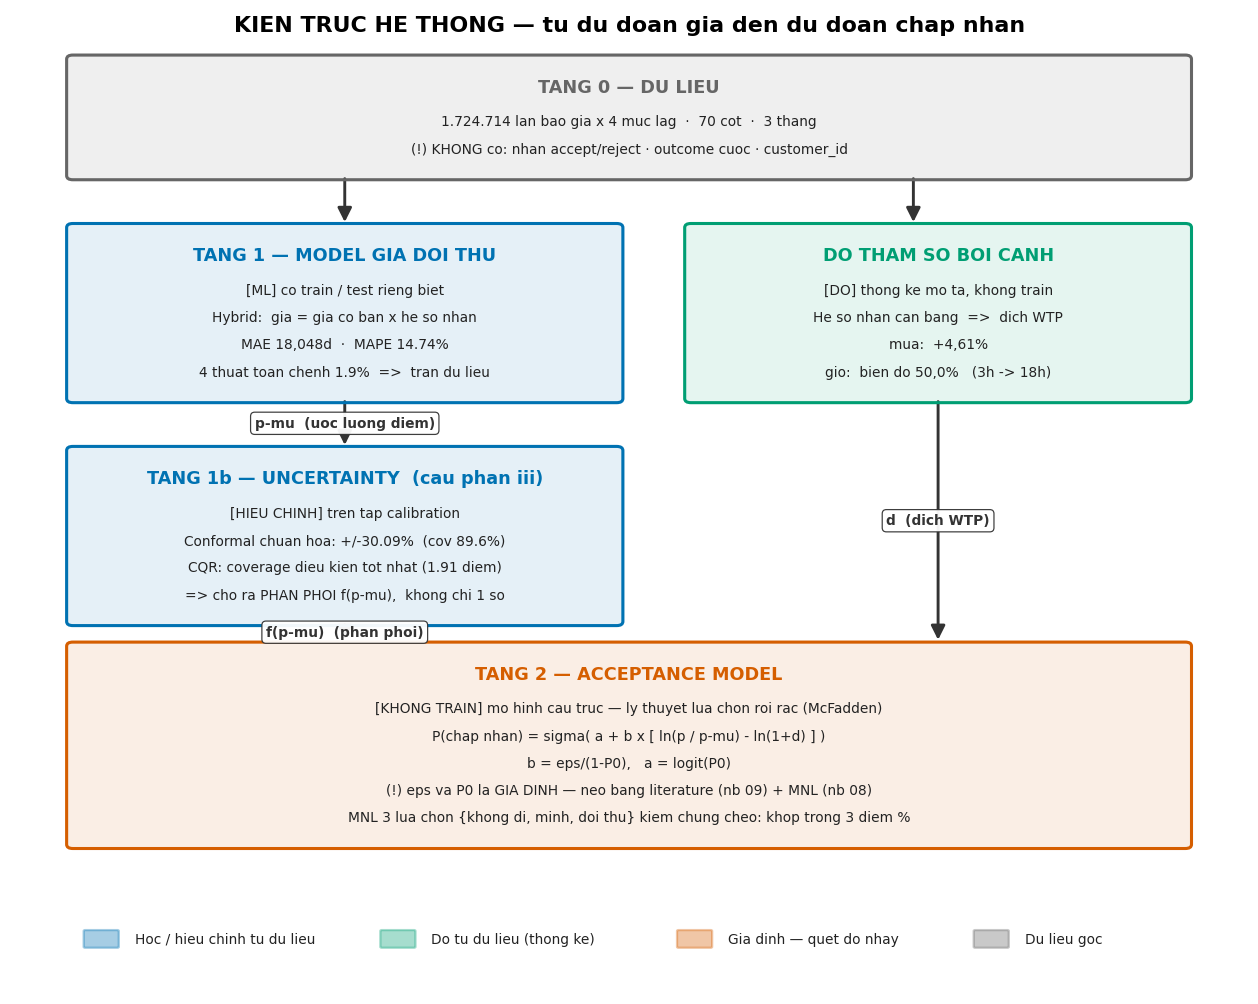

In [5]:
# ═════════ HINH KT1 — kien truc he thong ═════════
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

HOC, DO, GIADINH, CHAN = "#0072B2", "#009E73", "#D55E00", "#666666"


def ve_hop(ax, x, y, w, dong, tieu_de, mau, co_td=11.5, co_d=9.0, gian=3.3):
    # Hop TU DONG cao theo so dong -> khong bao gio tran chu ra ngoai khung
    h = 7.5 + gian * len(dong)
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5",
                                linewidth=2, edgecolor=mau, facecolor=mau,
                                alpha=0.10, zorder=1))
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5",
                                linewidth=2, edgecolor=mau, facecolor="none", zorder=3))
    ax.text(x + w/2, y + h - 3.4, tieu_de, ha="center", va="center",
            fontsize=co_td, fontweight="bold", color=mau, zorder=4)
    for i, d in enumerate(dong):
        ax.text(x + w/2, y + h - 7.6 - i*gian, d, ha="center", va="center",
                fontsize=co_d, color="#222", zorder=4)
    return h


def ten(ax, x1, y1, x2, y2, nhan="", mau="#333"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=19, linewidth=1.9, color=mau, zorder=2))
    if nhan:
        ax.text((x1+x2)/2, (y1+y2)/2, nhan, fontsize=9, color=mau, ha="center",
                va="center", fontweight="bold", zorder=5,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=mau, lw=0.8, alpha=.95))


fig, ax = plt.subplots(figsize=(14.5, 11.6))
ax.set_xlim(0, 100); ax.set_ylim(-13, 106); ax.axis("off")

ve_hop(ax, 5, 86, 90,
       ["1.724.714 lan bao gia x 4 muc lag  ·  70 cot  ·  3 thang",
        "(!) KHONG co: nhan accept/reject · outcome cuoc · customer_id"],
       "TANG 0 — DU LIEU", CHAN)
ten(ax, 27, 86, 27, 80.0)
ten(ax, 73, 86, 73, 80.0)

ve_hop(ax, 5, 59, 44,
       ["[ML] co train / test rieng biet",
        "Hybrid:  gia = gia co ban x he so nhan",
        "MAE {:,.0f}d  ·  MAPE {:.2%}".format(KQ["mae_hybrid"], KQ["mape_hybrid"]),
        "{} thuat toan chenh {:.1f}%  =>  tran du lieu".format(KQ["n_algo"], KQ["chenh_algo"])],
       "TANG 1 — MODEL GIA DOI THU", HOC)

ve_hop(ax, 55, 59, 40,
       ["[DO] thong ke mo ta, khong train",
        "He so nhan can bang  =>  dich WTP",
        "mua:  +4,61%",
        "gio:  bien do 50,0%   (3h -> 18h)"],
       "DO THAM SO BOI CANH", DO)

ten(ax, 27, 59, 27, 53.0, "p-mu  (uoc luong diem)")

ve_hop(ax, 5, 32, 44,
       ["[HIEU CHINH] tren tap calibration",
        "Conformal chuan hoa: +/-{:.2%}  (cov {:.1%})".format(KQ["q_rel"], KQ["cov_conf"]),
        "CQR: coverage dieu kien tot nhat ({:.2f} diem)".format(KQ["lech_cqr"]),
        "=> cho ra PHAN PHOI f(p-mu),  khong chi 1 so"],
       "TANG 1b — UNCERTAINTY  (cau phan iii)", HOC)

ten(ax, 27, 32, 27, 29.4, "f(p-mu)  (phan phoi)")
ten(ax, 75, 59, 75, 29.4, "d  (dich WTP)")

ve_hop(ax, 5, 5, 90,
       ["[KHONG TRAIN] mo hinh cau truc — ly thuyet lua chon roi rac (McFadden)",
        "P(chap nhan) = sigma( a + b x [ ln(p / p-mu) - ln(1+d) ] )",
        "b = eps/(1-P0),   a = logit(P0)",
        "(!) eps va P0 la GIA DINH — neo bang literature (nb 09) + MNL (nb 08)",
        "MNL 3 lua chon {khong di, minh, doi thu} kiem chung cheo: khop trong 3 diem %"],
       "TANG 2 — ACCEPTANCE MODEL", GIADINH)

# Chu thich — hang NGANG o day, tach hoan toan khoi cac hop
for i, (mau, nhan) in enumerate([
        (HOC, "Hoc / hieu chinh tu du lieu"),
        (DO, "Do tu du lieu (thong ke)"),
        (GIADINH, "Gia dinh — quet do nhay"),
        (CHAN, "Du lieu goc")]):
    xx = 6 + i*24
    ax.add_patch(FancyBboxPatch((xx, -7.4), 2.6, 1.9, boxstyle="round,pad=0.12",
                                linewidth=1.5, edgecolor=mau, facecolor=mau, alpha=.35))
    ax.text(xx + 4, -6.5, nhan, fontsize=9, va="center", color="#222")

ax.text(50, 103.5, "KIEN TRUC HE THONG — tu du doan gia den du doan chap nhan",
        ha="center", fontsize=14.5, fontweight="bold")

plt.savefig(HINH / "KT1_kien_truc_tang.png", bbox_inches="tight"); plt.show()

### Tầng 3 — Quyết định giá (áp dụng Tầng 2)

Tầng này **không được mentor yêu cầu** nhưng là thứ biến đường cong thành quy tắc dùng được.
Đã qua **hai lần sửa** quan trọng so với bản đầu.

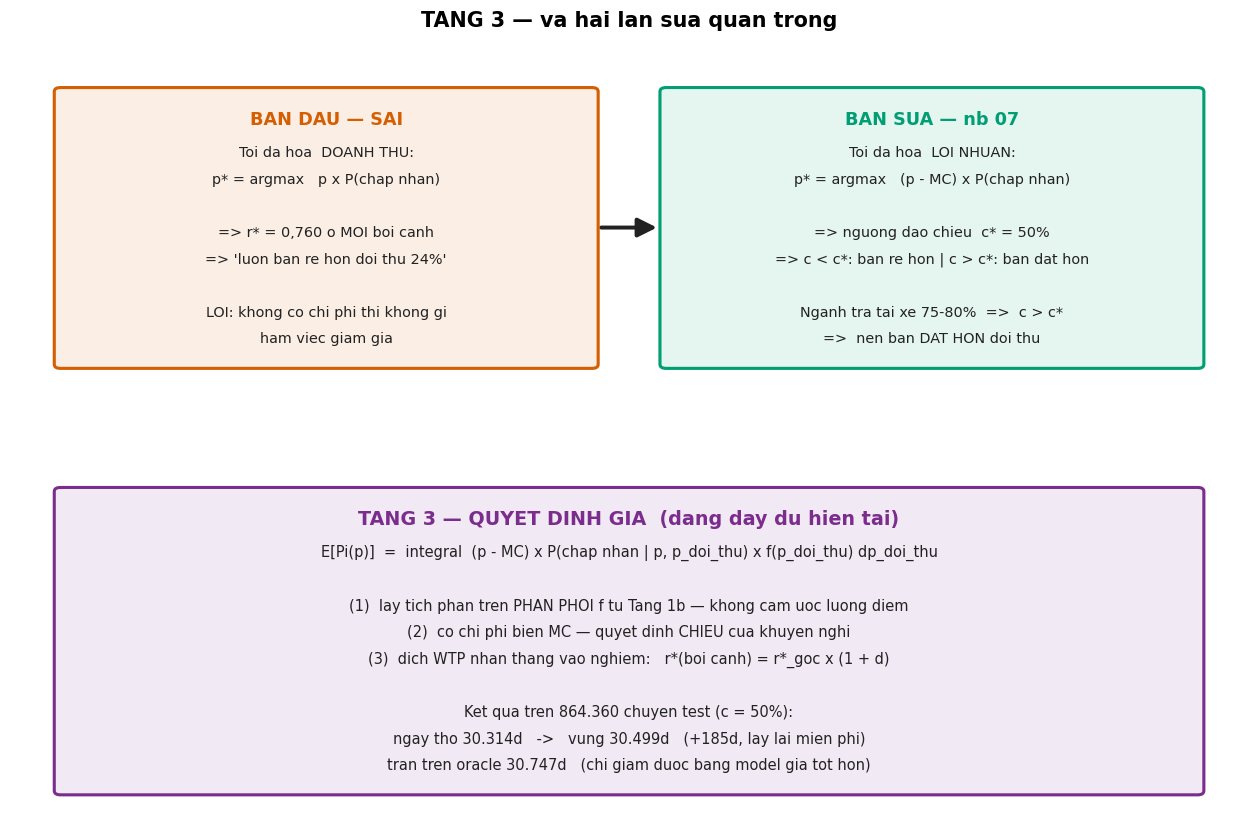

In [6]:
# ═════════ HINH KT2 — tang 3 va 2 lan sua ═════════
fig, ax = plt.subplots(figsize=(14.5, 9.5))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

ve_hop(ax, 4, 57, 43,
       ["Toi da hoa  DOANH THU:",
        "p* = argmax   p x P(chap nhan)",
        "",
        "=> r* = 0,760 o MOI boi canh",
        "=> 'luon ban re hon doi thu 24%'",
        "",
        "LOI: khong co chi phi thi khong gi",
        "ham viec giam gia"],
       "BAN DAU — SAI", RED, co_d=9.4)

ve_hop(ax, 53, 57, 43,
       ["Toi da hoa  LOI NHUAN:",
        "p* = argmax   (p - MC) x P(chap nhan)",
        "",
        "=> nguong dao chieu  c* = {:.0%}".format(KQ["c_star"]),
        "=> c < c*: ban re hon | c > c*: ban dat hon",
        "",
        "Nganh tra tai xe 75-80%  =>  c > c*",
        "=>  nen ban DAT HON doi thu"],
       "BAN SUA — nb 07", GREEN, co_d=9.4)

ax.add_patch(FancyArrowPatch((47.5, 74), (52.5, 74), arrowstyle="-|>",
                             mutation_scale=26, linewidth=2.6, color="#222"))

ve_hop(ax, 4, 4, 92,
       ["E[Pi(p)]  =  integral  (p - MC) x P(chap nhan | p, p_doi_thu) x f(p_doi_thu) dp_doi_thu",
        "",
        "(1)  lay tich phan tren PHAN PHOI f tu Tang 1b — khong cam uoc luong diem",
        "(2)  co chi phi bien MC — quyet dinh CHIEU cua khuyen nghi",
        "(3)  dich WTP nhan thang vao nghiem:   r*(boi canh) = r*_goc x (1 + d)",
        "",
        "Ket qua tren 864.360 chuyen test (c = 50%):",
        "ngay tho 30.314d   ->   vung 30.499d   (+185d, lay lai mien phi)",
        "tran tren oracle 30.747d   (chi giam duoc bang model gia tot hon)"],
       "TANG 3 — QUYET DINH GIA  (dang day du hien tai)", "#7B2D8E",
       co_td=12.5, co_d=9.6)

ax.text(50, 99, "TANG 3 — va hai lan sua quan trong",
        ha="center", fontsize=13.5, fontweight="bold")

plt.savefig(HINH / "KT2_tang3_quyet_dinh.png", bbox_inches="tight"); plt.show()

## Bảng tổng hợp — trạng thái toàn dự án

In [7]:
TRANG_THAI = pd.DataFrame([
    ("(i) Study relation", "✅ Xong",
     "Giờ tác động gấp 74× Boston · mưa +7,3% · giá cơ bản chỉ giải thích được 19%"),
    ("(ii) Build model", "✅ Xong",
     f"Hybrid MAE {KQ['mae_hybrid']:,.0f}đ ({KQ['mape_hybrid']:.1%}) · "
     f"{KQ['n_algo']} thuật toán chênh {KQ['chenh_algo']:.1f}%"),
    ("(iii) Uncertainty", "✅ Xong",
     f"Conformal ±{KQ['q_rel']:.1%} coverage {KQ['cov_conf']:.1%} · "
     f"CQR coverage điều kiện tốt nhất (lệch {KQ['lech_cqr']:.2f} vs {KQ['lech_qr']:.2f})"),
    ("(+) Acceptance — GĐ 1 logit + WTP", "✅ Xong",
     f"Tăng giá +10% → chấp nhận {KQ['chap_nhan_p10']:+.0%} (tương đối)"),
    ("(+) Acceptance — GĐ 2 kiểm chứng nội tại", "✅ Xong",
     "2.1 ✅ · 2.2 ✅ (nb 08) · 2.3 ✅ · 2.4 ✅ (nb 09) · 2.5 ✅"),
    ("(+) Acceptance — GĐ 3 MNL", "✅ Xong",
     f"s₀ = {KQ['s0']:.1%} · MNL khớp logit nhị phân trong 3 điểm %"),
    ("(+) Acceptance — GĐ 4 chính sách giá", "✅ Xong",
     f"Ngưỡng đảo chiều c* = {KQ['c_star']:.0%} (ngây thơ) / 44% (có UQ) · bảng tra cứu giờ × thời tiết"),
    ("(+) Acceptance — GĐ 5 tích hợp UQ", "✅ Xong",
     "Tích phân trên phân phối dự đoán · +0,61% ở c=50%"),
    ("(+) Acceptance — GĐ 6 backtest", "✅ Xong",
     f"{KQ['n_test']:,} chuyến · chi phí dự đoán sai 3.381đ/chuyến"),
    ("(+) Acceptance — GĐ 7-9 (có nhãn)", "🔒 Chặn",
     "Cần dữ liệu outcome từ mentor"),
], columns=["Hạng mục", "Trạng thái", "Kết quả chính"])

print("=" * 118)
print("TRANG THAI TOAN DU AN")
print("=" * 118)
display(TRANG_THAI)

xong = (TRANG_THAI["Trạng thái"].str.startswith("✅")).sum()
print(f"\n{xong}/{len(TRANG_THAI)} hang muc XONG · {len(TRANG_THAI)-xong} bi chan boi du lieu.")

TRANG THAI TOAN DU AN


,Hạng mục,Trạng thái,Kết quả chính
0,(i) Study relation,✅ Xong,"Giờ tác động gấp 74× Boston · mưa +7,3% · giá ..."
1,(ii) Build model,✅ Xong,"Hybrid MAE 18,048đ (14.7%) · 4 thuật toán chên..."
2,(iii) Uncertainty,✅ Xong,Conformal ±30.1% coverage 89.6% · CQR coverage...
3,(+) Acceptance — GĐ 1 logit + WTP,✅ Xong,Tăng giá +10% → chấp nhận -19% (tương đối)
4,(+) Acceptance — GĐ 2 kiểm chứng nội tại,✅ Xong,2.1 ✅ · 2.2 ✅ (nb 08) · 2.3 ✅ · 2.4 ✅ (nb 09) ...
5,(+) Acceptance — GĐ 3 MNL,✅ Xong,s₀ = 14.3% · MNL khớp logit nhị phân trong 3 đ...
6,(+) Acceptance — GĐ 4 chính sách giá,✅ Xong,Ngưỡng đảo chiều c* = 50% (ngây thơ) / 44% (có...
7,(+) Acceptance — GĐ 5 tích hợp UQ,✅ Xong,"Tích phân trên phân phối dự đoán · +0,61% ở c=50%"
8,(+) Acceptance — GĐ 6 backtest,✅ Xong,"864,360 chuyến · chi phí dự đoán sai 3.381đ/ch..."
9,(+) Acceptance — GĐ 7-9 (có nhãn),🔒 Chặn,Cần dữ liệu outcome từ mentor



9/10 hang muc XONG · 1 bi chan boi du lieu.


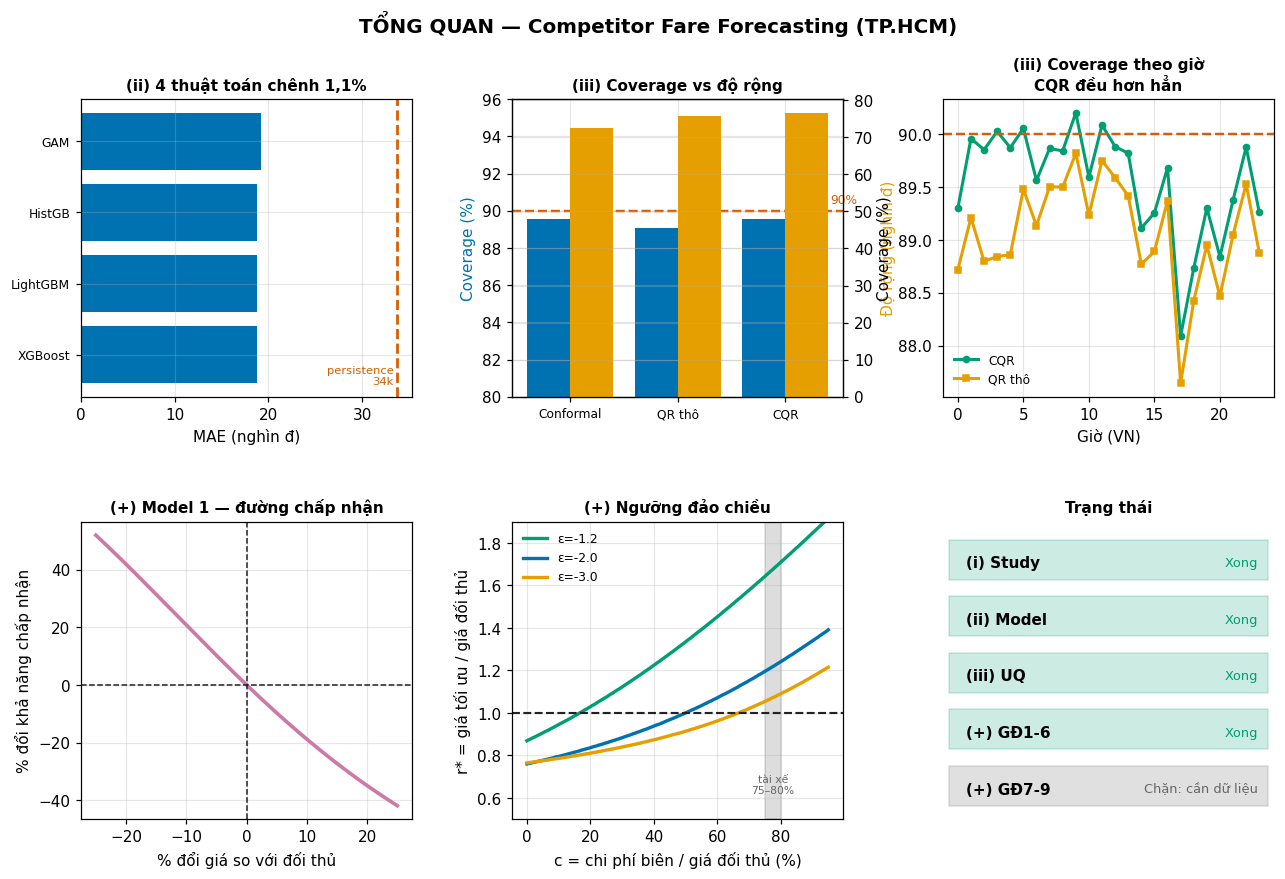

In [8]:
# ═════════ HINH TQ1 — bang dieu khien tong quan ═════════
fig = plt.figure(figsize=(14, 8.5))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30)

# (1) So sanh thuat toan
a = fig.add_subplot(gs[0, 0])
b2 = bang_algo[bang_algo["Thuật toán"] != "— Persistence (mốc so sánh)"]
a.barh(b2["Thuật toán"], b2["MAE (đ)"]/1000, color=BLUE)
a.axvline(mae_pers/1000, color=RED, ls="--", lw=1.8)
a.text(mae_pers/1000*0.99, -0.42, f"persistence\n{mae_pers/1000:.0f}k",
       fontsize=7.5, color=RED, ha="right")
a.set_xlabel("MAE (nghìn đ)"); a.tick_params(axis="y", labelsize=8)
a.set_title("(ii) 4 thuật toán chênh 1,1%", fontweight="bold", fontsize=10)

# (2) UQ
a = fig.add_subplot(gs[0, 1])
x = np.arange(3)
a.bar(x-0.2, [cov_conf*100, cov_qr*100, cov_cqr*100], 0.4, color=BLUE, label="coverage")
a.axhline(90, color=RED, ls="--", lw=1.6)
a.text(2.42, 90.4, "90%", fontsize=8, color=RED)
a2 = a.twinx()
a2.bar(x+0.2, [rong_conf/1000, rong_qr/1000, rong_cqr/1000], 0.4, color=ORANGE,
       label="độ rộng")
a.set_xticks(x); a.set_xticklabels(["Conformal", "QR thô", "CQR"], fontsize=8)
a.set_ylabel("Coverage (%)", color=BLUE); a.set_ylim(80, 96)
a2.set_ylabel("Độ rộng (nghìn đ)", color=ORANGE)
a.set_title("(iii) Coverage vs độ rộng", fontweight="bold", fontsize=10)

# (3) Coverage dieu kien
a = fig.add_subplot(gs[0, 2])
a.plot(byg.index, byg.trong_cqr, marker="o", lw=2, color=GREEN, ms=4, label="CQR")
a.plot(byg.index, byg.trong_qr, marker="s", lw=2, color=ORANGE, ms=4, label="QR thô")
a.axhline(90, color=RED, ls="--", lw=1.6)
a.set_xlabel("Giờ (VN)"); a.set_ylabel("Coverage (%)")
a.legend(frameon=False, fontsize=8)
a.set_title("(iii) Coverage theo giờ\nCQR đều hơn hẳn", fontweight="bold", fontsize=10)

# (4) Acceptance
a = fig.add_subplot(gs[1, 0])
pp = np.linspace(-0.25, 0.25, 200)
a.plot(pp*100, (P_accept(1+pp)/goc-1)*100, lw=2.4, color=PURPLE)
a.axhline(0, color="#222", ls="--", lw=1); a.axvline(0, color="#222", ls="--", lw=1)
a.set_xlabel("% đổi giá so với đối thủ"); a.set_ylabel("% đổi khả năng chấp nhận")
a.set_title("(+) Model 1 — đường chấp nhận", fontweight="bold", fontsize=10)

# (5) Nguong dao chieu
a = fig.add_subplot(gs[1, 1])
for eps, col in zip([-1.2, -2.0, -3.0], [GREEN, BLUE, ORANGE]):
    rr = np.array([toi_uu(c, eps) for c in cs])
    a.plot(cs*100, rr, lw=2.2, color=col, label=f"ε={eps}")
a.axhline(1.0, color="#222", ls="--", lw=1.4)
a.axvspan(75, 80, color=MUT, alpha=.22)
a.text(77.5, 0.62, "tài xế\n75–80%", fontsize=7, ha="center", color=MUT)
a.set_xlabel("c = chi phí biên / giá đối thủ (%)")
a.set_ylabel("r* = giá tối ưu / giá đối thủ"); a.set_ylim(0.5, 1.9)
a.legend(frameon=False, fontsize=8)
a.set_title("(+) Ngưỡng đảo chiều", fontweight="bold", fontsize=10)

# (6) Trang thai
a = fig.add_subplot(gs[1, 2]); a.axis("off")
a.set_title("Trạng thái", fontweight="bold", fontsize=10)
ten = ["(i) Study", "(ii) Model", "(iii) UQ", "(+) GĐ1-6", "(+) GĐ7-9"]
mau = [GREEN, GREEN, GREEN, GREEN, MUT]
txt = ["Xong", "Xong", "Xong", "Xong", "Chặn: cần dữ liệu"]
for i, (t, c_, s) in enumerate(zip(ten, mau, txt)):
    y = 0.86 - i*0.19
    a.add_patch(plt.Rectangle((0.02, y-0.055), 0.96, 0.135, color=c_, alpha=.20))
    a.text(0.07, y, t, fontsize=10, fontweight="bold", va="center")
    a.text(0.95, y, s, fontsize=8.5, va="center", ha="right", color=c_)

fig.suptitle("TỔNG QUAN — Competitor Fare Forecasting (TP.HCM)",
             fontsize=13, fontweight="bold", y=0.975)
plt.savefig(HINH / "TQ1_bang_dieu_khien.png"); plt.show()

## Ba giới hạn thật của toàn dự án

Đây là phần quan trọng nhất khi trình mentor — không phải kết quả, mà là **biết rõ mình không biết gì**.

| # | Giới hạn | Hệ quả |
|---|---|---|
| **1** | Dữ liệu **không có nhãn accept/reject** (`booking_or_completion_outcomes_generated = False`) | Acceptance model là **mô phỏng dưới giả định**, không phải model học từ dữ liệu. Đã kiểm chứng và loại trừ 8 hướng thay thế. |
| **2** | **Chi phí biên `c` chưa biết** | Quyết định **CHIỀU** của khuyến nghị giá. `c < c*` → bán rẻ hơn; `c > c*` → bán đắt hơn. Không tự trả lời được. |
| **3** | Model chỉ tái tạo ~62% dao động của giá cuối (nhưng ~96% của hệ số nhân) | Phần dư là **nhiễu thật** — đã chứng minh bằng `B5`: CV không giảm dù thu hẹp quãng đường tới 2 mét. |

## Câu hỏi gửi mentor — xếp theo giá trị mở khoá

Ô dưới in ra danh sách đã sắp xếp, kèm **thứ sẽ làm được ngay** khi có câu trả lời.

In [9]:
CAU_HOI = pd.DataFrame([
    (1, "Chi phí biên mỗi cuốc / tỷ lệ ăn chia tài xế?",
     "Chốt CHIỀU của toàn bộ khuyến nghị giá", "🔴 Cao nhất"),
    (2, "Team tối ưu GMV hay LỢI NHUẬN?",
     "Chọn giữa kết quả cũ (doanh thu) và nb 07 (lợi nhuận)", "🔴 Cao nhất"),
    (3, "Bao nhiêu % khách xem giá rồi KHÔNG đặt? (s₀)",
     "Chốt β ⇒ chốt CẢ HAI elasticity, hết phải giả định", "🔴 Cao"),
    (4, "Thị phần XanhSM vs đối thủ chính?",
     "Cùng với s₀ là đủ hiệu chỉnh MNL hoàn chỉnh", "🔴 Cao"),
    (5, "Công thức surge có NGƯỠNG NHẢY BẬC không?",
     "Mở khoá RD như Cohen 2016 ⇒ ước lượng ε THẬT từ dữ liệu lịch sử", "🟠 Vừa"),
    (6, "Có bộ dữ liệu 'giá đã hiện' + 'outcome' không?",
     "Mở khoá Nhánh B — supervised acceptance", "🟠 Vừa"),
    (7, "Xin được --artifact-profile full không?",
     "Thêm bảng quotes (có trường discount) — nghi là nguyên nhân sàn nhiễu", "🟡 Thấp"),
], columns=["#", "Câu hỏi", "Mở khoá", "Ưu tiên"])
display(CAU_HOI)

print("\n" + "═" * 78)
print("  NEU CHI HOI DUOC 2 CAU: hoi cau 1 va cau 3.")
print("  - Cau 1 quyet dinh CHIEU cua khuyen nghi (ban re hay ban dat hon doi thu)")
print("  - Cau 3 xoa bo gia dinh elasticity — thu duy nhat con dang phai doan")
print("═" * 78)

,#,Câu hỏi,Mở khoá,Ưu tiên
0,1,Chi phí biên mỗi cuốc / tỷ lệ ăn chia tài xế?,Chốt CHIỀU của toàn bộ khuyến nghị giá,🔴 Cao nhất
1,2,Team tối ưu GMV hay LỢI NHUẬN?,Chọn giữa kết quả cũ (doanh thu) và nb 07 (lợi...,🔴 Cao nhất
2,3,Bao nhiêu % khách xem giá rồi KHÔNG đặt? (s₀),"Chốt β ⇒ chốt CẢ HAI elasticity, hết phải giả ...",🔴 Cao
3,4,Thị phần XanhSM vs đối thủ chính?,Cùng với s₀ là đủ hiệu chỉnh MNL hoàn chỉnh,🔴 Cao
4,5,Công thức surge có NGƯỠNG NHẢY BẬC không?,Mở khoá RD như Cohen 2016 ⇒ ước lượng ε THẬT t...,🟠 Vừa
5,6,Có bộ dữ liệu 'giá đã hiện' + 'outcome' không?,Mở khoá Nhánh B — supervised acceptance,🟠 Vừa
6,7,Xin được --artifact-profile full không?,Thêm bảng quotes (có trường discount) — nghi l...,🟡 Thấp



══════════════════════════════════════════════════════════════════════════════
  NEU CHI HOI DUOC 2 CAU: hoi cau 1 va cau 3.
  - Cau 1 quyet dinh CHIEU cua khuyen nghi (ban re hay ban dat hon doi thu)
  - Cau 3 xoa bo gia dinh elasticity — thu duy nhat con dang phai doan
══════════════════════════════════════════════════════════════════════════════


## Việc còn mở

| Việc | Chặn bởi | Ghi chú |
|---|---|---|
| GAM trên **transformed feature space** | Chưa làm | Mentor gợi ý trao đổi với anh Khoa |
| Nâng MNL lên **Nested Logit** | Chưa cần | Chỉ cần nếu giả định IIA bị nghi ngờ |
| **RD quanh ngưỡng surge** | Câu hỏi 5 | Đường khả thi nhất để có `ε` thật |
| Nhánh B — supervised acceptance | Câu hỏi 6 | — |
| Đưa `UA*`, `MNL*`, `LIT1`, `TQ1` vào báo cáo tuần 3 | Không chặn | Trình bày |

---

## Bản đồ hình theo cấu phần

| Nhóm | Hình | Sinh bởi |
|---|---|---|
| (i) Study | `O1`,`O2`,`B1`–`B6`,`M1`–`M5`,`F1`–`F3`,`T1`,`T2` | `analysis/90_sinh_hinh_bao_cao_tuan2` |
| (ii) Model | `U1`–`U4`, `MT1`–`MT5` | `evaluation/06`, `evaluation/07` |
| (iii) UQ | `UQ1`–`UQ4` | `uncertainty/01`, `uncertainty/02` |
| (+) Acceptance | `AC1`–`AC7` | `acceptance/00_TONG_HOP` |
| (+) Chi phí biên & UQ | `UA1`–`UA5` | `acceptance/07` |
| (+) MNL | `MNL1`–`MNL3` | `acceptance/08` |
| (+) Literature | `LIT1` | `acceptance/09` |
| Tổng quan | `TQ1` | **notebook này** |